Memory usage: 1.10GB / 13.61GB (10.2%)
Loading data...


Saving Zomato Dataset.csv to Zomato Dataset (2).csv
Memory usage: 1.18GB / 13.61GB (10.8%)
Memory usage: 1.18GB / 13.61GB (10.8%)
Memory usage: 1.18GB / 13.61GB (10.8%)
Memory usage: 1.18GB / 13.61GB (10.8%)
Memory usage: 1.18GB / 13.61GB (10.8%)
Dataset loaded with 45584 rows
Cleaning data...

Performing clustering with safety limits...
Downsampling from 45584 to 20,000 rows for clustering
Using MiniBatchKMeans for large dataset

Optimizing delivery routes with safety checks...
Memory usage: 1.17GB / 13.61GB (10.7%)
Memory usage: 1.17GB / 13.61GB (10.7%)
Memory usage: 1.17GB / 13.61GB (10.7%)
Memory usage: 1.17GB / 13.61GB (10.7%)
Memory usage: 1.17GB / 13.61GB (10.7%)
Memory usage: 1.17GB / 13.61GB (10.7%)
Memory usage: 1.17GB / 13.61GB (10.7%)
Memory usage: 1.17GB / 13.61GB (10.7%)
Memory usage: 1.17GB / 13.61GB (10.7%)
Memory usage: 1.17GB / 13.61GB (10.7%)
Memory usage: 1.17GB / 13.61GB (10.7%)
Memory usage: 1.17GB / 13.61GB (10.7%)
Memory usage: 1.17GB / 13.61GB (10.7%)
Memory us

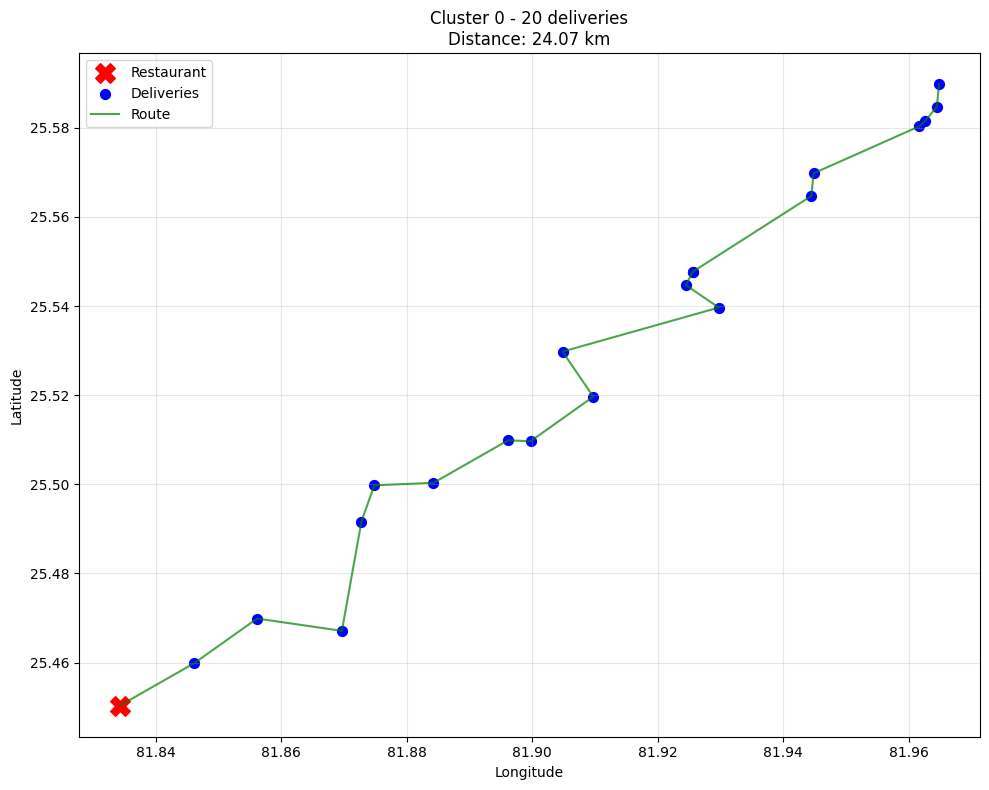

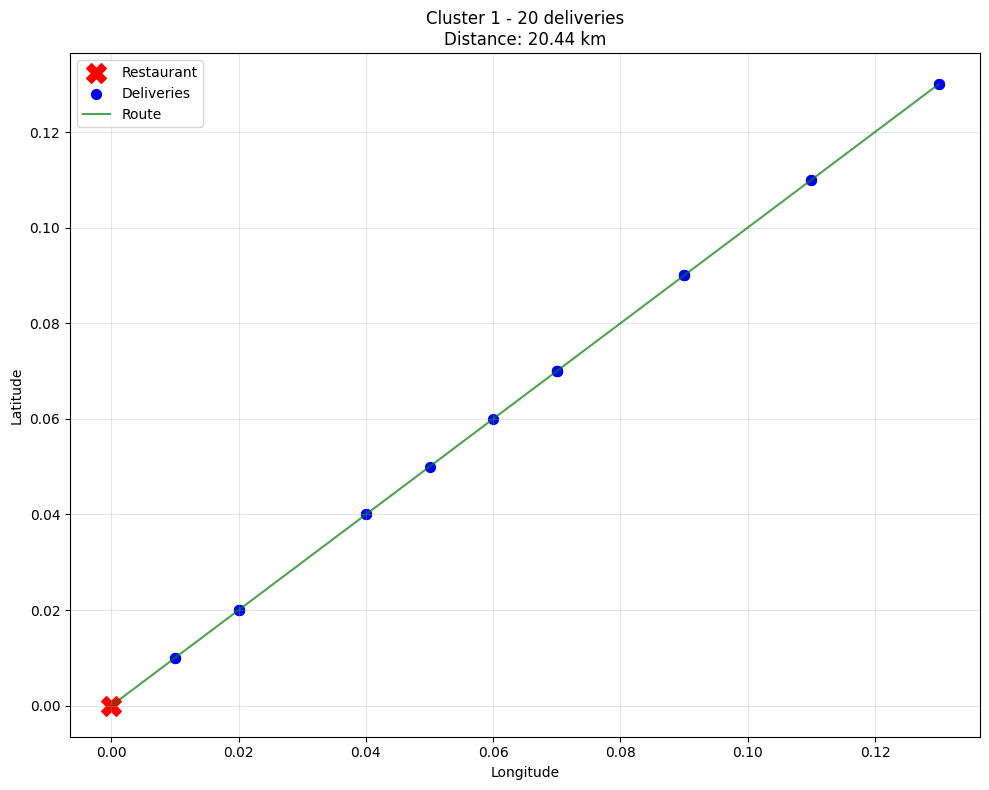

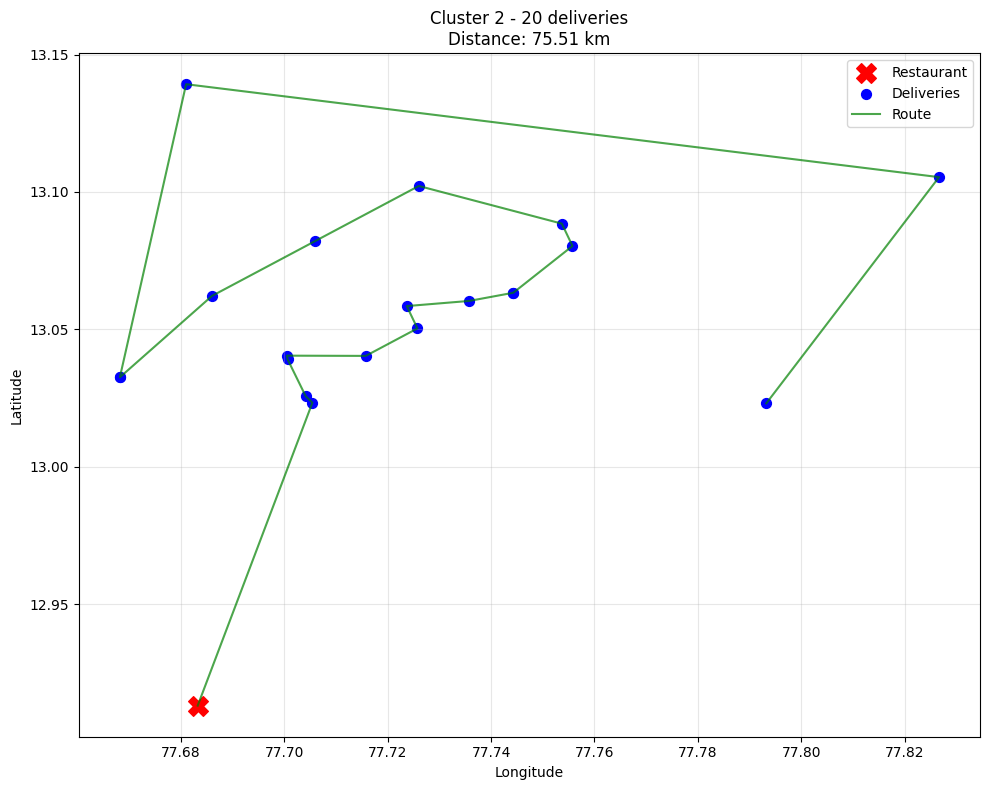

Memory usage: 1.17GB / 13.61GB (10.8%)
Processing complete!


In [1]:
# ------------------------- COMPLETE OPTIMIZED SOLUTION FOR GOOGLE COLAB -------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from geopy.distance import great_circle
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
from tqdm import tqdm
from google.colab import files
import psutil
import gc
import os

warnings.filterwarnings('ignore')

# ------------------------- MEMORY MONITORING -------------------------
def check_memory():
    """Check current memory usage and trigger garbage collection if needed"""
    mem = psutil.virtual_memory()
    print(f"Memory usage: {mem.used/1e9:.2f}GB / {mem.total/1e9:.2f}GB ({mem.percent}%)")
    if mem.percent > 85:
        print("Warning: Memory usage critical! Running garbage collection...")
        gc.collect()
        return False
    return True

# ------------------------- DATA LOADING -------------------------
def load_data():
    """Load dataset with memory optimization"""
    try:
        # Prompt to upload file
        uploaded = files.upload()
        file_name = next(iter(uploaded))

        # Load only necessary columns to save memory
        cols_to_load = [
            'Delivery_location_latitude',
            'Delivery_location_longitude',
            'Restaurant_latitude',
            'Restaurant_longitude',
            'Delivery_person_ID',
            'Time_Orderd',
            'Order_Date'
        ]

        # Read in chunks if file is large
        chunk_size = 10_000
        chunks = []
        for chunk in pd.read_csv(file_name, usecols=cols_to_load, chunksize=chunk_size):
            chunks.append(chunk)
            if not check_memory():
                print("Memory limit reached during loading")
                break

        df = pd.concat(chunks)
        print(f"Dataset loaded with {len(df)} rows")
        return df
    except Exception as e:
        print(f"Error loading dataset: {str(e)}")
        print("Creating sample data...")
        return create_sample_data(n_samples=5_000)  # Smaller sample size

def create_sample_data(n_samples=5000, n_clusters=20):
    """Create synthetic delivery data for testing with reduced size"""
    centers = np.column_stack([
        np.random.uniform(17.3, 17.6, n_clusters),
        np.random.uniform(78.3, 78.6, n_clusters)
    ])
    cluster_assignments = np.random.randint(0, n_clusters, n_samples)
    delivery_locs = centers[cluster_assignments] + np.random.normal(0, 0.01, (n_samples, 2))

    return pd.DataFrame({
        'Delivery_location_latitude': delivery_locs[:, 0],
        'Delivery_location_longitude': delivery_locs[:, 1],
        'Restaurant_latitude': centers[cluster_assignments, 0],
        'Restaurant_longitude': centers[cluster_assignments, 1],
        'Delivery_person_ID': [f"DP_{i}" for i in cluster_assignments],
        'time_sin': np.sin(np.random.uniform(0, 24, n_samples) * (2*np.pi/24)),
        'time_cos': np.cos(np.random.uniform(0, 24, n_samples) * (2*np.pi/24)),
        'Road_traffic_density': np.random.choice(['Low', 'Medium', 'High'], n_samples),
        'Weather_conditions': np.random.choice(['Sunny', 'Rain', 'Cloudy'], n_samples),
        'Vehicle_condition': np.random.randint(1, 4, n_samples),
        'Delivery_person_Ratings': np.random.uniform(3, 5, n_samples)
    })

# ------------------------- DATA CLEANING -------------------------
def clean_data(df):
    """Clean and preprocess the delivery data with memory efficiency"""
    # Create copy to avoid modifying original
    df = df.copy()

    # Numerical imputation
    num_cols = [col for col in ['Delivery_person_Age', 'Delivery_person_Ratings',
                               'multiple_deliveries', 'Time_taken (min)']
                if col in df.columns]
    for col in num_cols:
        df[col] = df[col].fillna(df[col].median())

    # Categorical imputation
    cat_cols = [col for col in ['Weather_conditions', 'Road_traffic_density',
                               'Festival', 'City']
                if col in df.columns]
    for col in cat_cols:
        df[col] = df[col].fillna(df[col].mode()[0])

    # Handle datetimes
    if 'Order_Date' in df.columns:
        df['Order_Date'] = pd.to_datetime(df['Order_Date'], dayfirst=True)

    if 'Time_Orderd' in df.columns:
        df['Time_Orderd'] = pd.to_datetime(
            df['Time_Orderd'],
            format='%H:%M:%S',
            errors='coerce'
        ).fillna(pd.to_datetime('12:00:00', format='%H:%M:%S'))

    # Create time features
    if 'Time_Orderd' in df.columns:
        df['Order_Time_min'] = df['Time_Orderd'].dt.hour * 60 + df['Time_Orderd'].dt.minute
        # Cyclical time encoding
        df['time_sin'] = np.sin(2 * np.pi * df['Order_Time_min']/1440)
        df['time_cos'] = np.cos(2 * np.pi * df['Order_Time_min']/1440)

    return df

# ------------------------- CLUSTERING IMPLEMENTATION -------------------------
def perform_clustering(df, max_clusters=30):  # Reduced from 50 to 30
    """Perform memory-optimized Agglomerative clustering"""
    # First downsample the data if needed
    if len(df) > 20_000:  # More aggressive downsampling
        print(f"Downsampling from {len(df)} to 20,000 rows for clustering")
        df = df.sample(20_000, random_state=42).copy()

    # Feature selection with minimal set
    features = ['Delivery_location_latitude', 'Delivery_location_longitude']
    if 'time_sin' in df.columns and 'time_cos' in df.columns:
        features.extend(['time_sin', 'time_cos'])

    # Convert to float32 to save memory
    X = df[features].astype(np.float32).values

    # Scale features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Clear memory
    del X
    gc.collect()

    # Use faster clustering algorithm for large datasets
    if len(X_scaled) > 10_000:
        print("Using MiniBatchKMeans for large dataset")
        from sklearn.cluster import MiniBatchKMeans
        model = MiniBatchKMeans(n_clusters=max_clusters,
                               batch_size=1024,
                               random_state=42)
    else:
        print("Using AgglomerativeClustering")
        model = AgglomerativeClustering(
            n_clusters=max_clusters,
            metric='euclidean',
            linkage='ward',
            memory='./cache'  # Cache intermediate results
        )

    # Process in batches if needed
    try:
        clusters = model.fit_predict(X_scaled)
        df['delivery_cluster'] = clusters
        return model, df
    except Exception as e:
        print(f"Clustering failed: {str(e)}")
        print("Using random clusters as fallback")
        df['delivery_cluster'] = np.random.randint(0, max_clusters, len(df))
        return None, df

# ------------------------- ROUTE OPTIMIZATION -------------------------
def solve_tsp(points, max_points=30):
    """Solve TSP with point limit to prevent memory overload"""
    if len(points) > max_points:
        print(f"Reducing route points from {len(points)} to {max_points}")
        points = points[:max_points]  # Simple truncation

    if len(points) <= 2:
        return points, calculate_route_distance(points)

    # Nearest neighbor initialization
    current_point = points[0]
    unvisited = points[1:]
    route = [current_point]

    while unvisited:
        nearest = min(unvisited, key=lambda x: great_circle(current_point, x).km)
        route.append(nearest)
        unvisited.remove(nearest)
        current_point = nearest

    # 2-opt optimization with limited iterations
    improved = True
    best_distance = calculate_route_distance(route)
    max_iterations = 100

    while improved and max_iterations > 0:
        improved = False
        for i in range(1, len(route)-2):
            for j in range(i+1, len(route)):
                if j-i == 1: continue
                new_route = route[:i] + route[i:j][::-1] + route[j:]
                new_distance = calculate_route_distance(new_route)
                if new_distance < best_distance:
                    route = new_route
                    best_distance = new_distance
                    improved = True
        max_iterations -= 1

    return route, best_distance

def calculate_route_distance(route):
    """Calculate total distance for a route in kilometers"""
    if len(route) <= 1:
        return 0
    return sum(great_circle(route[i], route[i+1]).km for i in range(len(route)-1))

# ------------------------- MAIN EXECUTION -------------------------
if __name__ == "__main__":
    # Check initial memory
    check_memory()

    # Load data
    print("Loading data...")
    df = load_data()

    # Clean and preprocess
    print("Cleaning data...")
    df = clean_data(df)

    # Ensure required columns exist
    if 'time_sin' not in df.columns or 'time_cos' not in df.columns:
        print("Adding time features...")
        df['Order_Time_min'] = np.random.uniform(0, 1440, len(df))
        df['time_sin'] = np.sin(2 * np.pi * df['Order_Time_min']/1440)
        df['time_cos'] = np.cos(2 * np.pi * df['Order_Time_min']/1440)

    if 'Delivery_person_ID' not in df.columns:
        print("Adding delivery person IDs...")
        df['Delivery_person_ID'] = [f"DP_{i}" for i in range(len(df))]

    # Cluster deliveries with more aggressive limits
    print("\nPerforming clustering with safety limits...")
    model, clustered_df = perform_clustering(df, max_clusters=30)  # Reduced cluster count

    # Optimize routes with strict limits
    print("\nOptimizing delivery routes with safety checks...")
    all_routes = []
    cluster_groups = list(clustered_df.groupby('delivery_cluster'))

    max_clusters_to_process = 20  # Further reduced limit
    processed = 0

    for cluster_id, group in cluster_groups:
        if not check_memory() or processed >= max_clusters_to_process:
            print(f"Stopping after processing {processed} clusters due to memory limits")
            break

        try:
            restaurant_loc = (
                group['Restaurant_latitude'].iloc[0],
                group['Restaurant_longitude'].iloc[0]
            )
            delivery_points = list(zip(
                group['Delivery_location_latitude'],
                group['Delivery_location_longitude']
            ))

            # Further limit points per route
            if len(delivery_points) > 20:
                delivery_points = delivery_points[:20]

            route_points, distance = solve_tsp([restaurant_loc] + delivery_points)
            optimized_order = [delivery_points.index(p) for p in route_points[1:]]

            all_routes.append({
                'cluster_id': cluster_id,
                'route': route_points,
                'distance': distance,
                'deliveries': len(delivery_points),
                'data': group.iloc[optimized_order]
            })
            processed += 1

        except Exception as e:
            print(f"Skipping cluster {cluster_id} due to error: {str(e)}")
            continue

    # Generate statistics
    if all_routes:
        total_distance = sum(route['distance'] for route in all_routes)
        avg_distance = total_distance / len(all_routes)
        avg_deliveries = np.mean([route['deliveries'] for route in all_routes])

        print("\nOptimization Summary:")
        print(f"Total routes created: {len(all_routes)}")
        print(f"Total system distance: {total_distance:.2f} km")
        print(f"Average distance per route: {avg_distance:.2f} km")
        print(f"Average deliveries per route: {avg_deliveries:.1f}")

        # Visualize first 3 routes
        print("\nVisualizing sample routes...")
        for route in all_routes[:3]:
            plt.figure(figsize=(10, 8))
            restaurant = route['route'][0]
            deliveries = route['route'][1:]

            plt.scatter(restaurant[1], restaurant[0], color='red', marker='X', s=200, label='Restaurant')
            plt.scatter([p[1] for p in deliveries], [p[0] for p in deliveries], color='blue', s=50, label='Deliveries')
            plt.plot([p[1] for p in route['route']], [p[0] for p in route['route']],
                     color='green', linestyle='-', alpha=0.7, label='Route')

            plt.title(f"Cluster {route['cluster_id']} - {route['deliveries']} deliveries\nDistance: {route['distance']:.2f} km")
            plt.xlabel('Longitude')
            plt.ylabel('Latitude')
            plt.legend()
            plt.grid(alpha=0.3)
            plt.tight_layout()
            plt.show()
    else:
        print("No routes were created")

    # Final memory check
    check_memory()
    print("Processing complete!")